# 03. ML-модели через mlforecast

Сравнение 3 ML-методов прогнозирования временного ряда.

Используются:

- LinearRegression;
- RandomForestRegressor;
- HistGradientBoostingRegressor.

Feature engineering выполняется через лаги и календарные признаки.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebook':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.ts_pipeline import (
    load_series,
    infer_frequency,
    infer_season_length,
    split_series,
    to_nixtla_df,
    forecast_metrics,
)

REPORT_DIR = PROJECT_ROOT / 'reports'
FIG_DIR = REPORT_DIR / 'figures'
REPORT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
TARGET_PATH = PROJECT_ROOT / 'data' / 'raw' / 'international-airline-passengers.csv'
series = load_series(TARGET_PATH, name='airline_passengers')

freq = infer_frequency(series)
season_length = infer_season_length(series)
train, test = split_series(series, test_size=12)
h = len(test)

train_df = to_nixtla_df(train, unique_id='airline_passengers')
print('freq:', freq, 'season_length:', season_length, 'h:', h)

freq: MS season_length: 12 h: 12


/home/osboxes/Desktop/project_neto_time_completion/src/ts_pipeline.py:73: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed.loc[regular] = pd.to_datetime(text.loc[regular], errors="coerce")


In [3]:
from mlforecast import MLForecast
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

models = [
    LinearRegression(),
    RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42),
    HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, random_state=42),
]

lags = [1, 2, 3, 6, 12]

fcst = MLForecast(
    models=models,
    freq=freq,
    lags=lags,
    date_features=['month', 'quarter'],
)

fcst.fit(train_df)
ml_pred = fcst.predict(h=h)
ml_pred

,unique_id,ds,LinearRegression,RandomForestRegressor,HistGradientBoostingRegressor
0,airline_passengers,1960-01-01,397.950160,414.065457,444.195794
1,airline_passengers,1960-02-01,374.540309,388.591989,406.614857
2,airline_passengers,1960-03-01,430.750578,452.839382,456.030916
3,airline_passengers,1960-04-01,438.866482,440.028373,454.701551
4,airline_passengers,1960-05-01,457.038807,469.157023,454.955490
5,airline_passengers,1960-06-01,510.673362,521.232963,469.676415
6,airline_passengers,1960-07-01,585.031587,545.243333,488.058374
7,airline_passengers,1960-08-01,614.919365,546.710000,488.058374
8,airline_passengers,1960-09-01,534.637867,520.472130,433.241033
9,airline_passengers,1960-10-01,453.052614,467.073029,424.230042


Для прогнозирования использованы три ML-модели: линейная регрессия, случайный лес и градиентный бустинг. Все модели получают одинаковый набор признаков: лаги `1, 2, 3, 6, 12`, а также календарные признаки `month` и `quarter`.

Лаг `12` особенно важен, потому что ряд имеет годовую сезонность: значение текущего месяца часто связано со значением того же месяца прошлого года. Лаги `1, 2, 3, 6` помогают учитывать ближайшую динамику и полугодовые изменения. Таблица `ml_pred` содержит прогнозы каждой модели на 12 месяцев тестового периода, поэтому далее можно сравнивать их с фактическими значениями по метрикам качества.

In [4]:
metric_rows = []
model_cols = [c for c in ml_pred.columns if c not in ['unique_id', 'ds']]

for col in model_cols:
    metrics = forecast_metrics(test.values, ml_pred[col].values)
    metrics['model'] = col
    metrics['group'] = 'ml'
    metrics['features'] = 'lags: 1,2,3,6,12; date_features: month,quarter'
    metric_rows.append(metrics)

ml_metrics = pd.DataFrame(metric_rows).sort_values('RMSE')
ml_metrics.to_csv(REPORT_DIR / 'mlforecast_comparison.csv', index=False)
ml_metrics

,MAE,RMSE,MAPE,sMAPE,model,group,features
0,17.180346,19.361013,3.563833,3.598926,LinearRegression,ml,"lags: 1,2,3,6,12; date_features: month,quarter"
1,24.468077,33.334823,4.850645,4.896580,RandomForestRegressor,ml,"lags: 1,2,3,6,12; date_features: month,quarter"
2,47.826691,62.766109,9.243700,9.738187,HistGradientBoostingRegressor,ml,"lags: 1,2,3,6,12; date_features: month,quarter"


### Вывод по метрикам ML-моделей

Лучший результат среди ML-моделей показала `LinearRegression`: RMSE = 19.36, MAE = 17.18, MAPE = 3.56%. Это означает, что средняя абсолютная ошибка прогноза составляет примерно 17 пассажиров, а средняя процентная ошибка - около 3.6%.

`RandomForestRegressor` занял второе место: RMSE = 33.33, MAPE = 4.85%. Модель уловила часть закономерностей, но оказалась менее точной, чем линейная регрессия. `HistGradientBoostingRegressor` показал самый слабый результат: RMSE = 62.77, MAPE = 9.24%.

Для такого короткого месячного ряда простая линейная модель оказалась сильнее сложных ансамблей. Вероятная причина - тренд и сезонность хорошо описываются лагами и календарными признаками, а более гибкие модели на небольшом количестве наблюдений могут хуже экстраполировать будущий тренд.

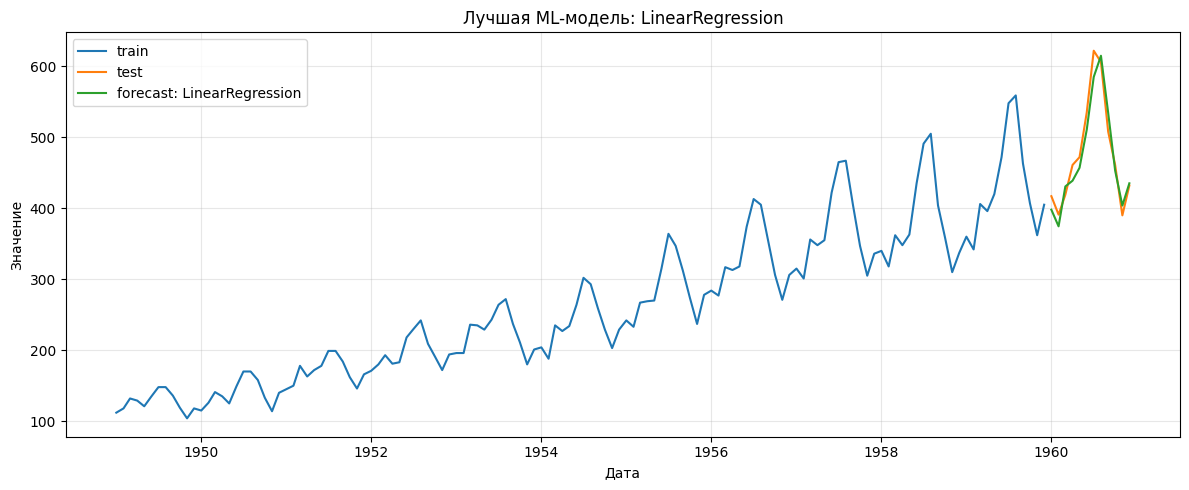

In [5]:
best_model = ml_metrics.iloc[0]['model']

plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label='train')
plt.plot(test.index, test.values, label='test')
plt.plot(test.index, ml_pred[best_model].values, label=f'forecast: {best_model}')
plt.title(f'Лучшая ML-модель: {best_model}')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'best_mlforecast_model.png', dpi=150)
plt.show()

### Вывод по графику лучшей ML-модели

На графике видно, что `LinearRegression` достаточно хорошо повторяет тестовый участок: прогноз сохраняет восходящий тренд и учитывает сезонный пик в середине года. Это согласуется с метриками, где линейная регрессия стала лучшей ML-моделью.

При этом прогноз не идеально совпадает с фактическими значениями в каждом месяце. Временной ряд короткий, а тестовая выборка включает только один год, поэтому результат лучше рассматривать как качество в рамках данного эксперимента, а не как универсальное доказательство превосходства линейной регрессии для любых рядов.

## Вывод

Проверен ML-подход к прогнозированию временного ряда авиапассажиров с помощью библиотеки `mlforecast`. Модели обучались не на исходной дате напрямую, а на признаках, сформированных из самого временного ряда: лагах `1, 2, 3, 6, 12` и календарных признаках `month`, `quarter`.

В ML-блоке лучший результат показала `LinearRegression` на лагах 1, 2, 3, 6, 12 и календарных признаках месяца/квартала: RMSE = 19.36, MAE = 17.18, MAPE = 3.56%. Это лучше статистического AutoARIMA на том же тестовом горизонте.

`RandomForestRegressor` занял второе место: RMSE = 33.33. `HistGradientBoostingRegressor` оказался слабее: RMSE = 62.77. Для короткого месячного ряда линейная модель выигрывает, потому что тренд и сезонность хорошо описываются лагами и календарными признаками, а более сложные ансамбли легче переобучаются.

Итог: ML-подход с простыми лаговыми признаками является конкурентным, но требует аккуратного временного split без перемешивания.